In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from econml.dml import CausalForestDML

import stats
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.inspection import partial_dependence
import numpy as np
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer
from sklearn.metrics import (
    silhouette_score, 
    r2_score,
)

import xgboost as xgb
from umap import UMAP
import shap

# =========================
# Custom utilities
# =========================
import utils.cross_validation as cval
import utils.umap_utils as uutil
import utils.exp_utils as exp

# =========================
# Optional helpers (math functions already included above)
# =========================
from math import radians, sin, cos, sqrt, asin
import math

In [2]:
# Essential Params and Dicts

color_map = {
    'Species Richness': 'grey',
    'Shannon Diversity': "#8040a0",
    "Raos_Q": 'darkolivegreen',
    "Simpson's Index":  "#cca9dd",
    'Functional_Evenness': "#94BC92"
}
biome_colors = {
    'Temperate broadleaf forests': "#4881BE",   # Sea Green (mid-tone green)
    'Temperate conifer forests':   "#016742",   # Very Dark Green (near-black green)
    'Temperate grasslands':        '#DAA520',   # Goldenrod (yellow-brown)
    'Xeric shrublands':             '#B5651D',   # Burnt Orange-Brown (desert)
    'Boreal and Tundra forests':    '#4169E1',   # Royal Blue (cool, distinct from green)
    'Mediterranean woodlands':      '#9ACD32',   # Yellow-Green (olive, warm-leaning)
    'Tropical':                     '#FF00FF',   # Magenta (maximally distinct, non-natural but unmistakable)
    'NaN':                          '#D3D3D3'    # Light Gray
}

with open("config/ex_config.yaml", "r") as f:
    config = yaml.safe_load(f)

biome_mapping = config["biome_mapping"]
random_key=config["random_key"]

biome_list=["Temperate broadleaf forests", "Temperate conifer forests", "Temperate grasslands",
            "Xeric shrublands", "Boreal and Tundra forests", "Tropical",
            "Mediterranean woodlands"]

In [3]:
"""
Causal Forest analysis: heterogeneous effect of functional diversity (Raos_Q)
on ecosystem productivity (transformed npp), moderated by water-stress /
climate index (WSCI).

Treatment (T):   Raos_Q
Outcome (Y):     transformed npp
Moderator (X):   WSCI          -> effect heterogeneity estimated as f(WSCI)
Confounders (W): everything else -> controlled for in nuisance models only

This uses econml.dml.CausalForestDML, which is a direct extension of the
Double/Debiased ML (DDML) framework you already used: it fits the same
Y ~ W and T ~ W nuisance models, but instead of a single average partial
effect it lets that effect vary flexibly as a function of X (here, WSCI)
via a causal forest.
"""



# pip install econml   (not installed in this sandbox, but this is the
# standard package: https://github.com/py-why/EconML)

# ---------------------------------------------------------------------------
# 1. Load & clean data (your existing pipeline)
# ---------------------------------------------------------------------------
fd_df = pd.read_csv('data/final/final_dataset.csv')
PID_df = pd.read_csv('data/lookup/PID_location_all.csv')

fd_df = fd_df.merge(PID_df[['PID', 'lat', 'lon', 'biome']], on='PID', how='left')

fd_df.dropna(
    subset=['transformed npp', 'Raos_Q', 'Functional_Evenness', 'Soil Moisture',
            'Species Richness', 'Shannon Diversity', "Simpson's Index", "pet_std"],
    inplace=True
)
fd_df = fd_df[fd_df["treecover2000"] > 30]
fd_df.drop_duplicates(subset=['PID'], inplace=True)

npp_df = pd.read_csv('data/processed/PID_npp_volatility.csv')
npp_df = npp_df[['PID', 'mean']]
fd_df = fd_df.merge(npp_df, on='PID', how='left')

fd_df['biome'] = fd_df['biome'].map(biome_mapping)  # only run once
fd_df = fd_df[fd_df["WSCI"] != 0]


In [16]:

# ---------------------------------------------------------------------------
# 2. Define Y, T, X (moderator), W (confounders)
# ---------------------------------------------------------------------------
outcome_col = 'transformed npp'
treatment_col = 'Raos_Q'
moderator_col = 'WSCI'

# Columns that are identifiers/geometry/leakage-prone, not confounders
non_feature_cols = {
    'PID', 'lat', 'mean','lon', 'geometry',  'treecover2000','Functional_Evenness', 'Functional_Richness', 'Species Richness', 'Shannon Diversity', "Simpson's Index",
    outcome_col, treatment_col, moderator_col,
    'mean',            # NPP volatility - drop if not intended as a confounder;
                        # move to outcome_col instead if you meant to use it
}

# Everything else = confounders (W)
confounder_cols = [c for c in fd_df.columns if c not in non_feature_cols]

# One-hot encode any categorical confounders (e.g. biome, if not numeric)
fd_model_df = fd_df.copy()
categorical_confounders = [
    c for c in confounder_cols if fd_model_df[c].dtype == 'object'
]
if categorical_confounders:
    fd_model_df = pd.get_dummies(
        fd_model_df, columns=categorical_confounders, drop_first=True
    )
    # rebuild confounder_cols after dummy expansion
    confounder_cols = [
        c for c in fd_model_df.columns
        if c not in non_feature_cols and c not in categorical_confounders
    ]

# Drop any remaining non-numeric confounder columns defensively
confounder_cols = [
    c for c in confounder_cols if pd.api.types.is_numeric_dtype(fd_model_df[c])
]

Y = fd_model_df[outcome_col].values
T = fd_model_df[treatment_col].values
X = fd_model_df[[moderator_col]].values      # heterogeneity dimension
W = fd_model_df[confounder_cols].values      # controls only

print(f"N = {len(fd_model_df)}")
print(f"Confounders used ({len(confounder_cols)}): {confounder_cols}")


N = 51718
Confounders used (13): ['Annual Temp', 'Annual Precipitation', 'Precipitation Seasonality', 'Soil Moisture', 'SOC Content', 'Burnt Areas Probability', 'Elevation', 'Slope', 'Depth to Bedrock', 'Northness', 'pet_std', 'disturbance_value', 'land_cover_value']


In [17]:

# ---------------------------------------------------------------------------
# 3. Fit CausalForestDML
# ---------------------------------------------------------------------------
# Nuisance models: same idea as your DDML first stage (Y~W, T~W).
# Swap in whatever learners you used in DDML (e.g. GradientBoosting, LassoCV)
# for consistency with that analysis.

xgb_params = dict(
    objective='reg:squarederror',
    learning_rate=0.01,
    max_depth=6,
    min_child_weight=2,
    gamma=0.1,
    reg_lambda=1.0,
    reg_alpha=0.0,
    tree_method='hist',   # you listed 'hist' then 'approx' — a dict can only keep one, pick one
    n_estimators=500,
    random_state=21,
)


model_y = xgb.XGBRegressor(**xgb_params)   # nuisance model for Y ~ X  (outcome regression)
model_t = xgb.XGBRegressor(**xgb_params)   # nuisance model for Y ~ X  (outcome regression)
 
est = CausalForestDML(
    model_y=model_y,
    model_t=model_t,
    discrete_treatment=False,   # Raos_Q is continuous
    n_estimators=2000,
    min_samples_leaf=10,
    max_depth=None,
    honest=True,                # honest splitting, as in Wager & Athey
    cv=5,  
    n_jobs=-1,                     # cross-fitting folds for nuisance models
    random_state=42,
)
 
est.fit(Y, T, X=X, W=W, cache_values=True)  # cache_values=True needed for
                                             # population summary / heterogeneity test below
 


In [18]:
# ---------------------------------------------------------------------------
# 4. Estimate heterogeneous effects across the range of WSCI
# ---------------------------------------------------------------------------
wsci_grid = np.linspace(
    fd_model_df[moderator_col].min(),
    fd_model_df[moderator_col].max(),
    100
).reshape(-1, 1)

cate_pred = est.effect(wsci_grid)
lb, ub = est.effect_interval(wsci_grid, alpha=0.05)  # 95% CI


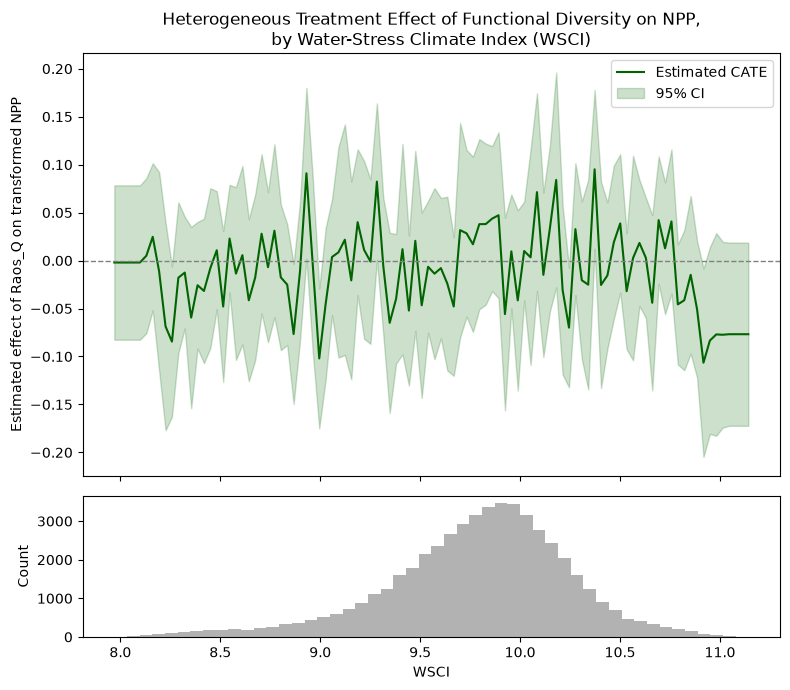

In [19]:

# ---------------------------------------------------------------------------
# 5. Plot: how the Raos_Q -> NPP effect changes with WSCI
# ---------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(8, 7), sharex=True,
    gridspec_kw={'height_ratios': [3, 1]}
)

ax1.plot(wsci_grid, cate_pred, color='darkgreen', label='Estimated CATE')
ax1.fill_between(wsci_grid.ravel(), lb, ub, color='darkgreen', alpha=0.2,
                  label='95% CI')
ax1.axhline(0, color='gray', linestyle='--', linewidth=1)
ax1.set_ylabel('Estimated effect of Raos_Q on transformed NPP')
ax1.set_title('Heterogeneous Treatment Effect of Functional Diversity on NPP,\nby Water-Stress Climate Index (WSCI)')
ax1.legend()

# WSCI histogram underneath, on the same x-axis, so you can see whether
# wiggles/wide-CI regions in the CATE curve line up with sparse data
ax2.hist(fd_model_df[moderator_col], bins=50, color='gray', alpha=0.6)
ax2.set_xlabel('WSCI')
ax2.set_ylabel('Count')

plt.tight_layout()
plt.savefig('cate_by_wsci.png', dpi=200)
plt.show()


In [22]:

# ---------------------------------------------------------------------------
# 6. Overall average effect + summary, for comparison against your DDML ATE
# ---------------------------------------------------------------------------
ate = est.ate(X)
ate_lb, ate_ub = est.ate_interval(X, alpha=0.05)
print(f"\nAverage Treatment Effect (Raos_Q -> transformed npp): {ate:.4f}")
print(f"95% CI: [{ate_lb:.4f}, {ate_ub:.4f}]")

# Test whether treatment effect heterogeneity w.r.t. WSCI is statistically
# significant (heterogeneity test via linear projection: is CATE a
# significant linear function of WSCI, i.e. does WSCI explain any of the
# variation in the Raos_Q -> NPP effect?)
het_results = est.summary()
print("\nCausal Forest summary (linear heterogeneity test):")
print(het_results)

# Pull the coefficient + p-value out explicitly instead of relying on the
# raw printed table. est.summary() returns a statsmodels-style Summary
# object; the underlying coefficient table is in .tables[0] as a
# SimpleTable, so we convert it to a DataFrame.
try:
    coef_table = het_results.tables[0]
    coef_df = pd.DataFrame(coef_table.data[1:], columns=coef_table.data[0])
    print("\nParsed heterogeneity coefficient table:")
    print(coef_df)

    # The row for the WSCI moderator's coefficient is what tells you
    # whether WSCI significantly predicts the size of the Raos_Q effect.
    # Column names can vary slightly by econml version - inspect coef_df
    # if the row lookup below doesn't match your output.
    wsci_row = coef_df[coef_df.iloc[:, 0].astype(str).str.contains('X0|WSCI', case=False)]
    if not wsci_row.empty:
        print("\nWSCI heterogeneity coefficient (is WSCI a significant moderator?):")
        print(wsci_row)
    else:
        print("\nCould not auto-locate the WSCI row - inspect coef_df above manually.")
except Exception as e:
    print(f"\nCould not parse summary table automatically ({e}). "
          f"Inspect het_results directly - print(het_results) above shows the raw table.")


Average Treatment Effect (Raos_Q -> transformed npp): 0.0022
95% CI: [-0.0884, 0.0928]
Population summary of CATE predictions on Training Data
Doubly Robust ATE on Training Data Results:  Doubly Robust ATE calculation on training data is available only on discrete treatments!
Doubly Robust ATT on Training Data Results:  Doubly Robust ATT calculation on training data is available only on discrete treatments!

Causal Forest summary (linear heterogeneity test):
               Uncertainty of Mean Point Estimate              
mean_point stderr_mean zstat pvalue ci_mean_lower ci_mean_upper
---------------------------------------------------------------
     0.002       0.046 0.048  0.962        -0.088         0.093
      Distribution of Point Estimate     
std_point pct_point_lower pct_point_upper
-----------------------------------------
    0.045          -0.083           0.093
     Total Variance of Point Estimate     
stderr_point ci_point_lower ci_point_upper
--------------------------


--- Raos_Q effect across 6 WSCI quintile groups ---
 group  wsci_min  wsci_max  wsci_median    n  effect     se  ci_lower  ci_upper  significant
     0    7.9698    9.3939       9.1407 8620 -0.0059 0.0350   -0.0746    0.0627        False
     1    9.3940    9.6538       9.5416 8620 -0.0407 0.0521   -0.1429    0.0614        False
     2    9.6538    9.8334       9.7485 8619 -0.0738 0.0431   -0.1583    0.0108        False
     3    9.8334    9.9925       9.9133 8620  0.0452 0.0341   -0.0217    0.1120        False
     4    9.9926   10.1860      10.0811 8619 -0.0593 0.0302   -0.1186   -0.0001         True
     5   10.1860   11.1415      10.3424 8620 -0.0246 0.0497   -0.1219    0.0727        False


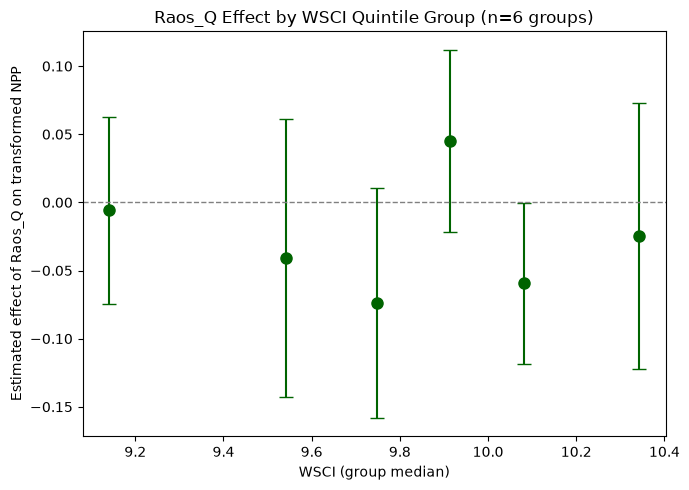

In [27]:

# ---------------------------------------------------------------------------
# 7. Split WSCI into n quantile-based groups: is the Raos_Q effect
#    significant within each group, and do the groups differ from each other?
# ---------------------------------------------------------------------------
n_groups = 6
 
# Assign each row to a WSCI quintile group (0 = lowest, 4 = highest)
fd_model_df['wsci_group'] = pd.qcut(
    fd_model_df[moderator_col], q=n_groups, labels=False
)
 
group_results = []
for g in range(n_groups):
    group_mask = fd_model_df['wsci_group'] == g
    group_wsci_vals = fd_model_df.loc[group_mask, moderator_col]
 
    # Representative WSCI value for this group: use the group median
    # (more robust to skew within the group than the mean)
    rep_val = group_wsci_vals.median()
    rep_point = np.array([[rep_val]])
 
    inf = est.effect_inference(rep_point)
    effect = inf.point_estimate[0]
    se = inf.stderr[0]
    ci = inf.conf_int(alpha=0.05)
 
    group_results.append({
        'group': g,
        'wsci_min': group_wsci_vals.min(),
        'wsci_max': group_wsci_vals.max(),
        'wsci_median': rep_val,
        'n': group_mask.sum(),
        'effect': effect,
        'se': se,
        'ci_lower': ci[0][0],
        'ci_upper': ci[1][0],
    })
 
group_df = pd.DataFrame(group_results)
group_df['significant'] = ~((group_df['ci_lower'] < 0) & (group_df['ci_upper'] > 0))
 
print(f"\n--- Raos_Q effect across {n_groups} WSCI quintile groups ---")
print(group_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
 
# Plot: effect estimate + CI per group, as a quick visual complement to the
# continuous CATE curve above
plt.figure(figsize=(7, 5))
plt.errorbar(
    group_df['wsci_median'], group_df['effect'],
    yerr=[group_df['effect'] - group_df['ci_lower'],
          group_df['ci_upper'] - group_df['effect']],
    fmt='o', color='darkgreen', capsize=5, markersize=8
)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel('WSCI (group median)')
plt.ylabel('Estimated effect of Raos_Q on transformed NPP')
plt.title(f'Raos_Q Effect by WSCI Quintile Group (n={n_groups} groups)')
plt.tight_layout()
plt.savefig('cate_by_wsci_groups.png', dpi=200)
plt.show()
 